In [1]:
import sys
from pathlib import Path
import pandas as pd
from datetime import datetime, timedelta

sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from utils import *

In [3]:
def pipeline_ticker(ticker: str, model, scaler, backtest_params: dict,strategy) -> dict:
    
    print('Iniciando Pipeline para el ticker:',{ticker})
    print('---'*15)
    
    try: 
        df = extract_clean_ticker(ticker,start='2011-01-01',end='2025-06-01', interval='1d')    
        df['date'] = pd.to_datetime(df['date'])
        
        if df.empty: 
            return None
        df = añadir_indicadores_tecnicos(df)
        

        df['price_vs_kijun'] = df['close'] - df['ichimoku_base']
        df['tenkan_vs_kijun'] = df['ichimoku_conversion'] - df['ichimoku_base']


        df = df.dropna()
        features = [
            'rsi', 'macd_diff', 'bollinger_width', 'atr', 'adx', 
            'volume_ratio', 'price_vs_kijun', 'tenkan_vs_kijun']
        X = df[features]
        X_scaled=scaler.transform(X)
        
        df['ml_signal'] = model.predict(X_scaled)
        
        results = strategy(
            df,
            signal_col='ml_signal',
            **backtest_params
        )
        

        results['Ticker'] = ticker
        print(f"Pipeline para {ticker} completado.")
        return results

    except Exception as e:
        print(f"ERROR: No se pudo completar la pipeline para {ticker}. Causa: {e}")
        return None

In [4]:
#Cargar modelo y scaler.
with open('../models/best_models/xgboost_best_model.pkl', 'rb') as f: 
    ml_model = pickle.load(f)
with open('../models/models_num/scaler_num.pkl', 'rb') as f:
    scaler = pickle.load(f)

In [ ]:
params = {
    'monthly_invest': 100, 
    'trade_amount': 150, 
    'take_profit_pct': 0.125, 
    'initial_trading_cash': 5000, 
    'verbose': True 
}



In [17]:
resultado_dow_jhon = pipeline_ticker(
    ticker='DIA', 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params,
    strategy=backtest_dca_plus_trading_WITH_SL
)

Iniciando Pipeline para el ticker: {'DIA'}
---------------------------------------------


Resultados para: ml_signal (Con SL)
Valor Final del Portafolio: $47,753.83
Retorno Porcentual: 123.15%
Posiciones Abiertas al Final: 17
Valor de Posiciones Abiertas: $2,650.89
Sharpe Ratio: 1.22

Valor Final del Portafolio: $47,753.83
Total Aportado: $21,400.00

Trading PnL: $4,960.77
Capital Usado en Trading: $117,600.00

Total DCA Shares: 89.48

Pipeline para DIA completado.


In [18]:
resultado_SP500 = pipeline_ticker(
    ticker='VOO', 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params,
    strategy=backtest_dca_plus_trading_WITH_SL)

Iniciando Pipeline para el ticker: {'VOO'}
---------------------------------------------
Resultados para: ml_signal (Con SL)
Valor Final del Portafolio: $58,056.94
Retorno Porcentual: 171.29%
Posiciones Abiertas al Final: 4
Valor de Posiciones Abiertas: $643.82
Sharpe Ratio: 1.35

Valor Final del Portafolio: $58,056.94
Total Aportado: $21,400.00

Trading PnL: $8,207.87
Capital Usado en Trading: $103,350.00

Total DCA Shares: 82.96

Pipeline para VOO completado.


Iniciando Pipeline para el ticker: {'QQQ'}
---------------------------------------------
Resultados para: ml_signal (Self-Sufficient)
Valor Final del Portafolio: $41,732.17
Total Aportado: $11,600.00
Retorno Absoluto: $30,132.17
Retorno Porcentual: 259.76%
Trading PnL: $1,618.71
Capital Usado en Trading: $23,700.00
Posiciones Abiertas al Final: 0
Valor de Posiciones Abiertas: $0.00
Total DCA Shares: 80.45
Valor DCA Shares: $41,713.45
Sharpe Ratio: 0.79



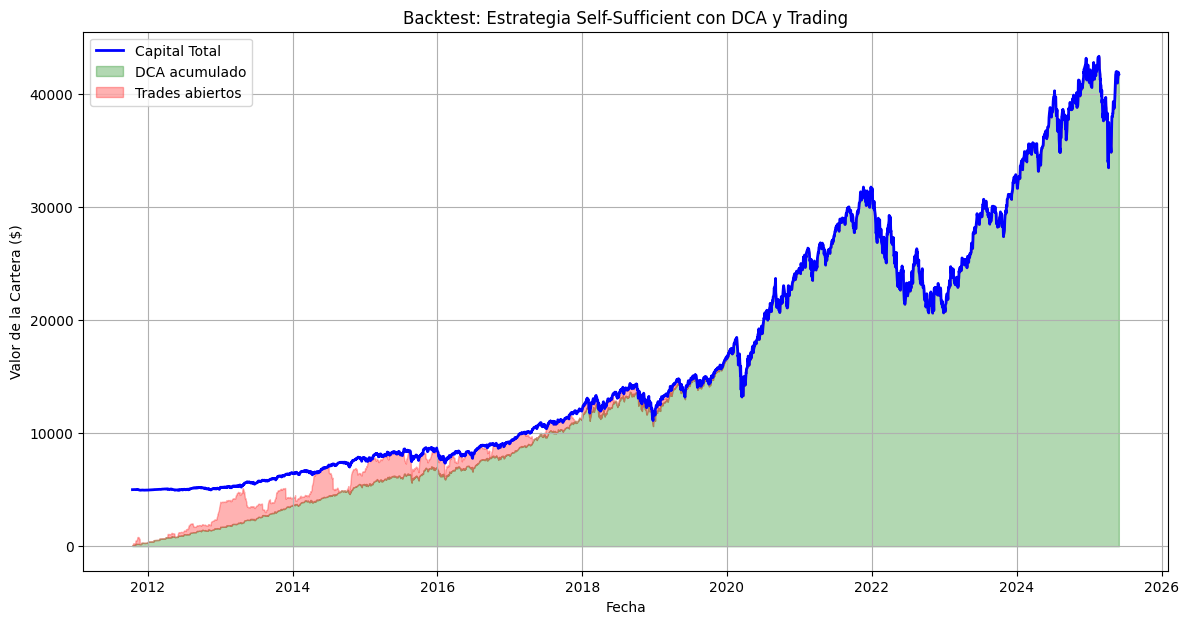

Pipeline para QQQ completado.


In [8]:
resultado_nasdaq = pipeline_ticker(
    ticker='QQQ', 
    model=ml_model, 
    scaler=scaler, 
    backtest_params=params,
    strategy=backtest_dca_self_sufficient
)